In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df_original = pd.read_parquet('../Imdb_Movie_Dataset.parquet')
print("Dados carregados. Preparando o gerador de dados sintéticos (SMOTE)!")

Dados carregados. Preparando o gerador de dados sintéticos (SMOTE)!


In [11]:
df = df_original.copy()

cond_nota = df['vote_average'] >= 6.8
cond_vmin = df['vote_count'] >= 20
cond_vmax = df['vote_count'] <= 3000
df['sucesso_nicho'] = (cond_nota & cond_vmin & cond_vmax).astype(int)

df['release_year'] = pd.to_datetime(df['release_date'], format='mixed', errors='coerce').dt.year
df['genres_limpo'] = df['genres'].astype(str).str.replace(r'[\(\)\[\]\']', '', regex=True).str.replace(' ', '')
df_genres = df['genres_limpo'].str.get_dummies(sep=',').add_prefix('genero_')

top_idiomas = df['original_language'].value_counts().head(5).index
df['idioma_agrupado'] = df['original_language'].where(df['original_language'].isin(top_idiomas), 'outros')
df_idiomas = pd.get_dummies(df['idioma_agrupado'], prefix='idioma', dtype=int)

pistas_numericas = df[['runtime', 'revenue', 'release_year']].fillna(0)
X = pd.concat([pistas_numericas, df_genres, df_idiomas], axis=1)
y = df['sucesso_nicho']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

In [13]:
print(f"Antes do SMOTE, tínhamos {y_train.sum()} sucessos de nicho no treino.")

# 1. A Mutação dos Dados (SMOTE)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Depois do SMOTE, temos {y_train_smote.sum()} sucessos de nicho no treino. A base está 50/50!")

# 2. Criando e Treinando o Modelo Campeão
modelo_lgbm_smote = LGBMClassifier(random_state=42, n_jobs=-1)
modelo_lgbm_smote.fit(X_train_smote, y_train_smote)

print("Treinamento concluído com sucesso! O modelo_lgbm_smote agora existe na memória.")

Antes do SMOTE, tínhamos 11557 sucessos de nicho no treino.
Depois do SMOTE, temos 749687 sucessos de nicho no treino. A base está 50/50!
[LightGBM] [Info] Number of positive: 749687, number of negative: 749687
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.105390 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 815
[LightGBM] [Info] Number of data points in the train set: 1499374, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Treinamento concluído com sucesso! O modelo_lgbm_smote agora existe na memória.


=== RESULTADOS DO MODELO (LIGHTGBM + SMOTE) ===
                  precision    recall  f1-score   support

     Filme Comum       0.99      0.89      0.94    187326
Sucesso de Nicho       0.07      0.50      0.12      2985

        accuracy                           0.89    190311
       macro avg       0.53      0.70      0.53    190311
    weighted avg       0.98      0.89      0.93    190311



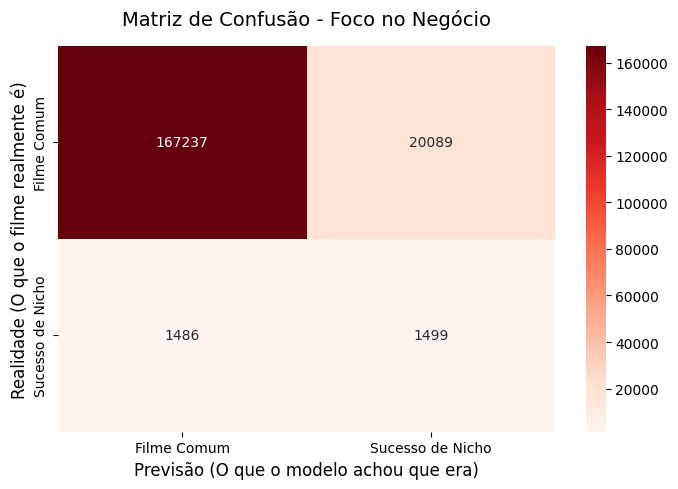

In [14]:
# 1. Fazendo as previsões com o modelo treinado com SMOTE
previsoes_smote = modelo_lgbm_smote.predict(X_test)

# 2. Traduzindo o Relatório de Texto (Classification Report)
nomes_das_classes = ['Filme Comum', 'Sucesso de Nicho']

print("=== RESULTADOS DO MODELO (LIGHTGBM + SMOTE) ===")
print(classification_report(y_test, previsoes_smote, target_names=nomes_das_classes))

# 3. Traduzindo o Gráfico (Matriz de Confusão)
plt.figure(figsize=(7,5))

# Adicionamos o xticklabels e yticklabels para forçar os nomes em vez de 0 e 1
sns.heatmap(
    confusion_matrix(y_test, previsoes_smote), 
    annot=True, 
    fmt='d', 
    cmap='Reds', 
    xticklabels=nomes_das_classes, 
    yticklabels=nomes_das_classes
)

plt.title('Matriz de Confusão - Foco no Negócio', fontsize=14, pad=15)
plt.ylabel('Realidade (O que o filme realmente é)', fontsize=12)
plt.xlabel('Previsão (O que o modelo achou que era)', fontsize=12)

# Ajusta o layout para os nomes não ficarem cortados
plt.tight_layout()
plt.show()